In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from utils.config import Config
from sklearn.metrics import roc_auc_score

root_dir = Path("G:/My Drive/Architectural-Biases-in-Time-Series-Anomaly-Detection")
cfg = Config(
    root_dir,
    "saved_model_weights",
    "training",
    "training_results",
    "data.csv",
    "training_checkpoints"
)

In [26]:
data = np.load(cfg.training_results / "exp_1_" / "scores_labels_cats_k=3.npz")
residuals, scores, labels, categories = data["residuals"], data["scores"], data["labels"], data["categories"]

FileNotFoundError: [Errno 2] No such file or directory: 'G:\\My Drive\\Architectural-Biases-in-Time-Series-Anomaly-Detection\\training\\training_results\\exp_1_\\scores_labels_cats_k=3.npz'

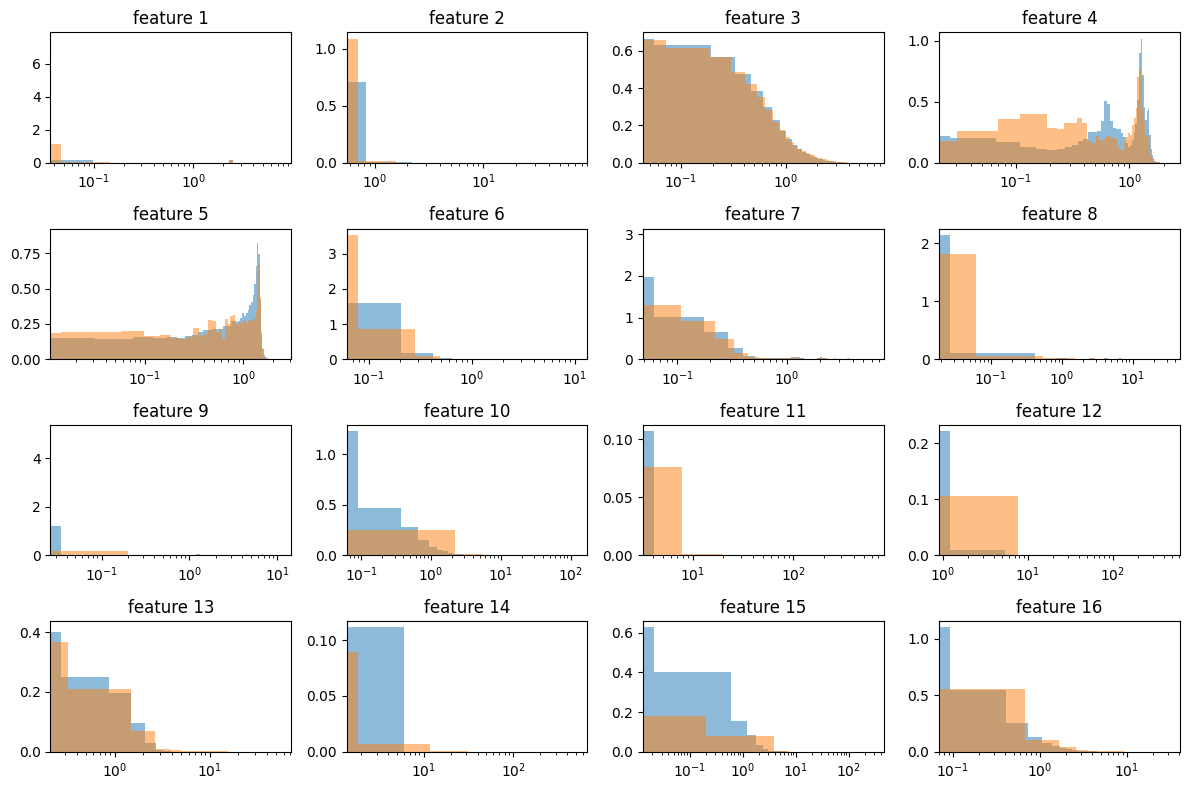

In [ ]:
res = residuals.reshape((2499740, 4, 17)).mean(axis = 1)

fig, axes = plt.subplots(4, 4, figsize = (12, 8))
axes = axes.flatten()
for i in range(0, 16):

    axes[i].hist(res[labels == 0, i], density=True, label = "normal", bins = 100, alpha = 0.5)
    axes[i].hist(res[labels != 0, i], density=True, label = "anomaly", bins = 100, alpha = 0.5)
    axes[i].set_title(f"feature {i + 1}")
plt.tight_layout()
plt.show()

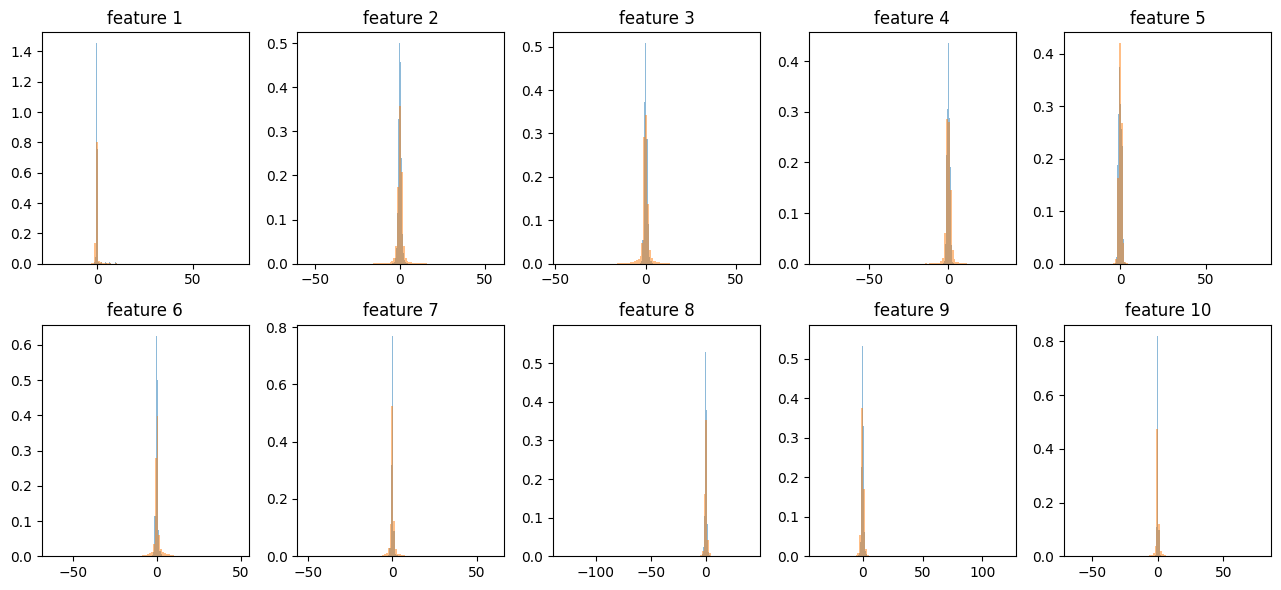

In [ ]:

fig, axes = plt.subplots(2, 5, figsize = (13, 6))
axes = axes.flatten()
for i in range(0, 10):

    axes[i].hist(res_reduced[labels == 0, i], density=True, label = "normal", bins = 100, alpha = 0.5)
    axes[i].hist(res_reduced[labels != 0, i], density=True, label = "anomaly", bins = 100, alpha = 0.5)
    axes[i].set_title(f"feature {i + 1}")
plt.tight_layout()
plt.show()

In [4]:
data = pd.read_csv("data.csv")

In [5]:
data.head()

,timestamp,aimp,amud,arnd,asin1,asin2,adbr,adfl,bed1,bed2,bfo1,bfo2,bso1,bso2,bso3,ced1,cfo1,cso1,y,category
0,2023-01-01 00:00:00,0.0,1.0,20.000000,0.00000,0.0000,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
1,2023-01-01 00:00:01,0.0,1.0,20.080031,0.00002,0.0002,0.0,0.0,0.0,0.0,0.0,4.993912e-07,0.000789,0.0,0.0,0.0,0.000021,0.001229,0.0,0.0
2,2023-01-01 00:00:02,0.0,1.0,20.276562,0.00004,0.0004,0.0,0.0,0.0,0.0,0.0,1.496957e-06,0.003115,0.0,0.0,0.0,0.000104,0.004833,0.0,0.0
3,2023-01-01 00:00:03,0.0,1.0,20.730938,0.00006,0.0006,0.0,0.0,0.0,0.0,0.0,2.991484e-06,0.006914,0.0,0.0,0.0,0.000285,0.010688,0.0,0.0
4,2023-01-01 00:00:04,0.0,1.0,21.118101,0.00008,0.0008,0.0,0.0,0.0,0.0,0.0,4.981761e-06,0.012123,0.0,0.0,0.0,0.000601,0.018669,0.0,0.0


In [12]:
data_clean = data.drop(columns = ["timestamp", "y", "category"])[:1000000]

In [21]:
pd.concat([data_clean[:700000].mean(), data_clean[700000:850000].mean(), data_clean[850000:].mean()], axis = 1)

,0,1,2
aimp,0.010097,0.009987,0.010240
amud,-2.663729,-0.498173,-6.164967
arnd,21.921882,22.045278,19.482134
asin1,0.061661,0.137307,-0.227755
asin2,0.008555,-0.037858,0.015031
adbr,0.497291,0.495253,0.507653
adfl,0.604357,0.601067,0.601600
bed1,1.009478,0.999044,1.024624
bed2,0.201919,0.199843,0.204801
bfo1,11.073947,11.194270,9.987965


In [24]:
pd.concat([
    data_clean[:800000].std(),
    data_clean[800000:].std(),
], axis=1)

,0,1
aimp,0.100051,0.099794
amud,10.045469,8.784626
arnd,10.922039,9.124337
asin1,0.690228,0.609356
asin2,0.707472,0.708030
adbr,0.499998,0.499999
adfl,0.489049,0.489704
bed1,0.713776,0.696019
bed2,0.321614,0.320811
bfo1,11.614009,10.132140
